In [2]:
import pandas as pd
from datasets import load_dataset 
dataset= load_dataset("cardiffnlp/tweet_eval", "sentiment")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [3]:
df_test = dataset["test"].to_pandas()
print(df_test.shape)

(12284, 2)


In [1]:
from transformers import pipeline 
classifier = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment")

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [5]:
result = classifier("I absolutely love this!")
print(result)

[{'label': 'LABEL_2', 'score': 0.9896766543388367}]


In [8]:
texts=df_test["text"].tolist()
results=classifier(texts)

In [9]:
y_pred_bert = [int(result["label"][-1]) for result in results]

In [17]:
from sklearn.metrics import accuracy_score, classification_report
print(accuracy_score(df_test['label'],y_pred_bert))
print(classification_report(df_test['label'],y_pred_bert,target_names=['Negative','Neutral','Positive']))

0.7244382937154021
              precision    recall  f1-score   support

    Negative       0.71      0.78      0.74      3972
     Neutral       0.74      0.69      0.71      5937
    Positive       0.72      0.71      0.71      2375

    accuracy                           0.72     12284
   macro avg       0.72      0.73      0.72     12284
weighted avg       0.73      0.72      0.72     12284



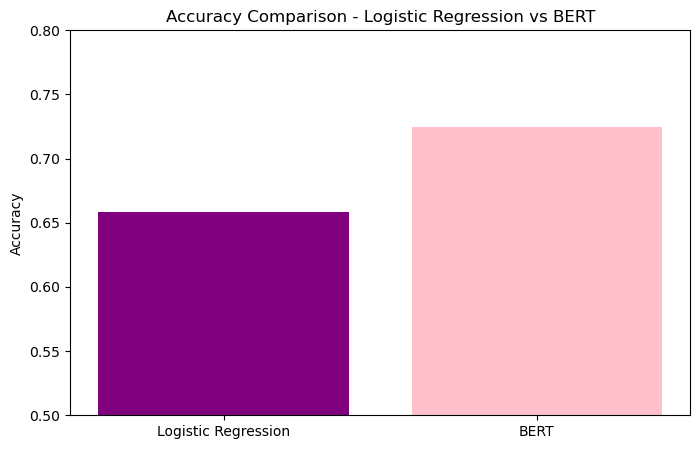

In [24]:
import matplotlib.pyplot as plt
models = ["Logistic Regression", "BERT"]
accuracies = [0.6585,0.7244]
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies,color=['purple','pink'])
plt.ylim(0.5, 0.8)
plt.title('Accuracy Comparison - Logistic Regression vs BERT')
plt.ylabel('Accuracy')
plt.show()

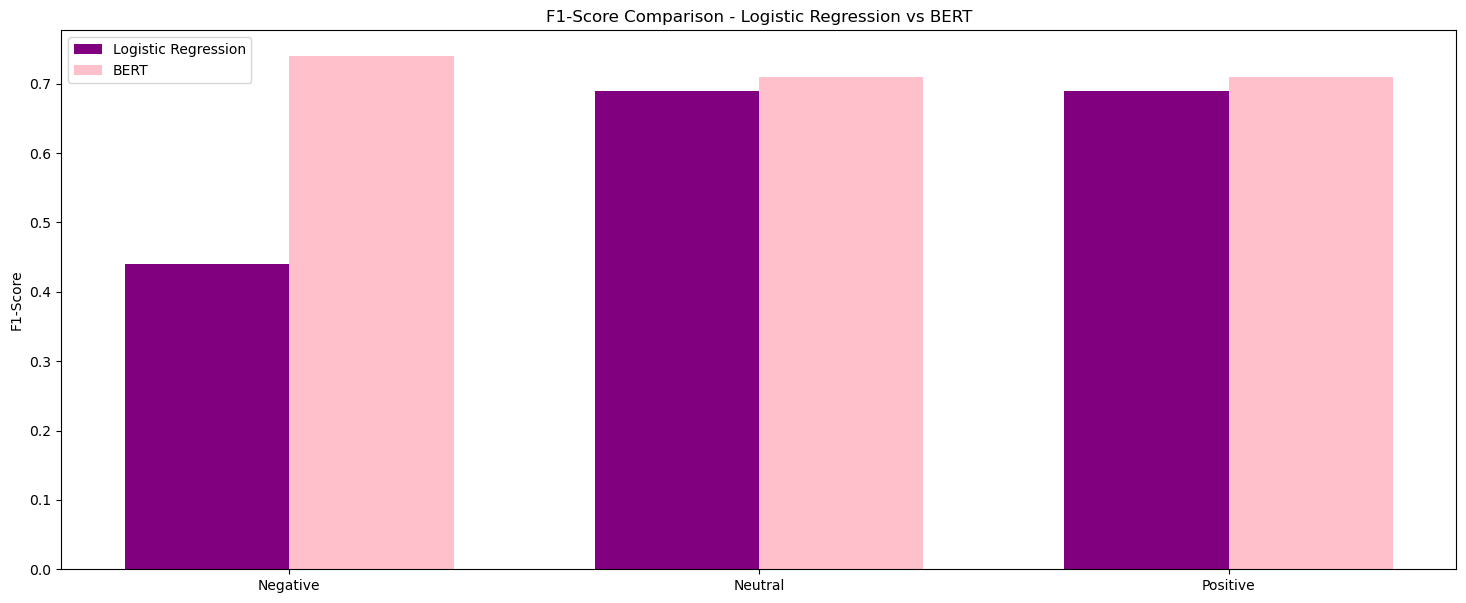

In [30]:
import numpy as np
classes=["Negative", "Neutral", "Positive"]
lr_f1 = [0.44, 0.69, 0.69]
bert_f1 = [0.74, 0.71, 0.71]
x = np.arange(len(classes))
width = 0.35
plt.figure(figsize=(18, 7))
plt.bar(x-width/2,lr_f1,width,label="Logistic Regression",color="purple")
plt.bar(x+width/2,bert_f1, width,label="BERT", color="pink")
plt.xticks(x, classes)
plt.legend()
plt.title('F1-Score Comparison - Logistic Regression vs BERT')
plt.ylabel('F1-Score')
plt.show()

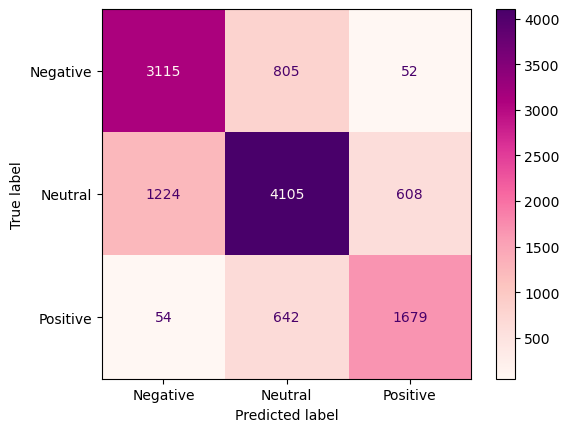

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm=confusion_matrix(df_test['label'],y_pred_bert)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Negative','Neutral','Positive'])
disp.plot(cmap="RdPu")
plt.show()
